Data shape: (600, 1001)

Using encapsulated selective stacking algorithm...
Selected 355/600 signals

Training neural network...
Training neural network using encapsulated code...
Epoch [1/200], Total Loss: 0.2825, SNR Loss: 0.1818, Sym Loss: 0.6857
Epoch [50/200], Total Loss: 0.0398, SNR Loss: 0.0216, Sym Loss: 0.1145
Epoch [100/200], Total Loss: 0.0280, SNR Loss: 0.0145, Sym Loss: 0.0834
Epoch [150/200], Total Loss: 0.0217, SNR Loss: 0.0115, Sym Loss: 0.0640
Epoch [200/200], Total Loss: 0.0200, SNR Loss: 0.0103, Sym Loss: 0.0603
Training complete!
Model saved to: ./models/model_encapsulated.pt

Applying trained model...

Result comparison:
Linear stacking SNR: 3.7362
Selective stacking SNR: 2.8296
Neural network stacking SNR: 81.6968


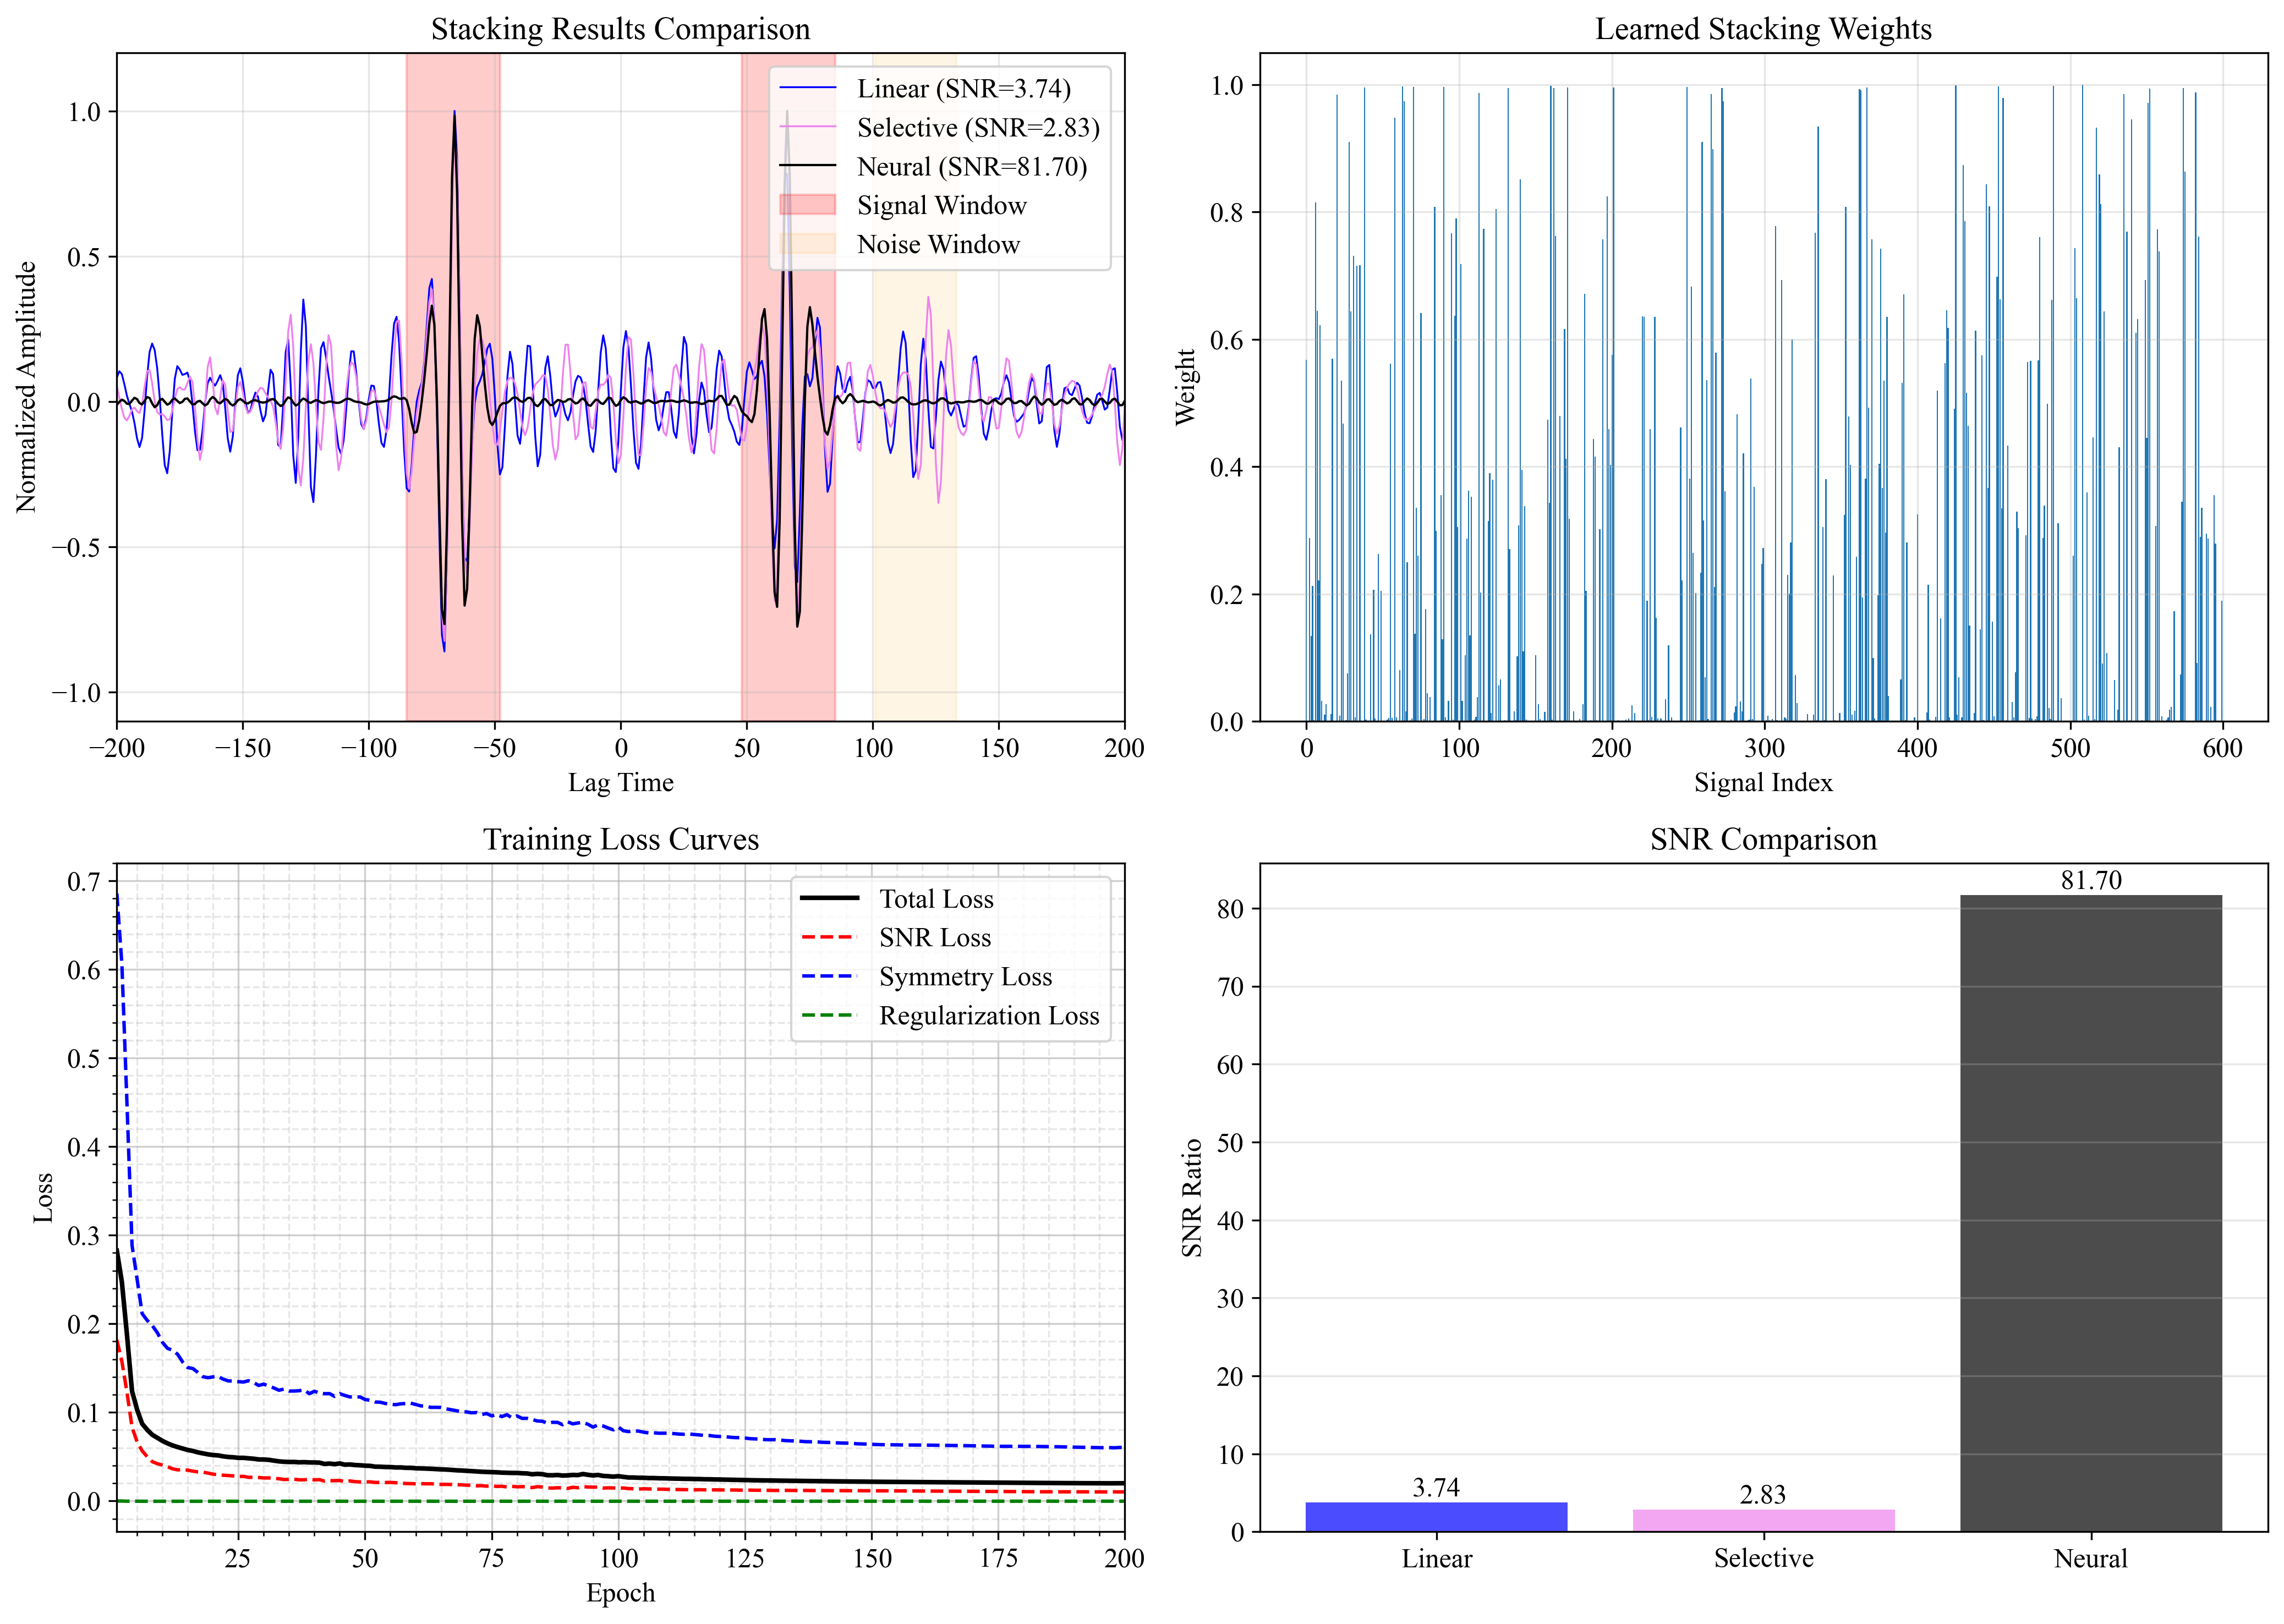

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import sys
import os

# Add path to encapsulated code
# sys.path.append(os.path.dirname(os.path.abspath(__file__)))

# Import encapsulated neural network modules
from main import *

# Set default data type
torch.set_default_dtype(torch.float32)

# ==============================================================================
# Differences from encapsulated code - need your own adjustments
# ==============================================================================

"""
Note: The following are differences from the encapsulated code that you need to adjust based on your requirements:

1. Noise window in calculate_rms_ratio function:
   - In encapsulated code: noise_win2 = syme[tmax+2*tau_idx:]
   - In your code: noise_win2 = syme[tmax+6*tau:tmax+10*tau]
   
2. Threshold G in rmsr_ss function:
   - In encapsulated code: G = 1 + 1 / n_segments
   - In your code: G = 1 + 5 / n_segments
   
3. Your code uses specific loss function calculations, different from encapsulation:
   - SNRLoss forward method has special implementation
   - SymLoss signal_energy function returns torch.max(sym) instead of torch.sqrt(torch.mean(sym**2, dim=-1))
   
4. Different neural network architecture:
   - StackingNet in encapsulation uses lag and delta parameters
   - Your code directly uses num_channels parameter
   
5. Your code has specific index calculations (e.g., data[:,:501] and data[:,500:])
"""

# ==============================================================================
# Implementation using encapsulated code
# ==============================================================================

def norm(a, axis=1):
    """Normalization function, consistent with original code"""
    if a.ndim == 1:
        return a / np.abs(a).max()
    else:
        return a / np.abs(a).max(axis=axis).reshape(-1, 1)

def ratio4(data, tau, tmin, tmax, delta):
    """SNR calculation function, completely consistent with original code"""
    tau = int(tau/delta)
    tmin = int(tmin/delta)
    tmax = int(tmax/delta)
    length = len(data)
    zero_lag = int(length/2)
    
    left = data[:zero_lag+1]
    right = data[zero_lag:]
    left = left[::-1]
    syme = np.sum(np.vstack((left, right)), 0)
    
    signal = syme[tmin-2*tau:tmax+2*tau]
    trail = syme[tmax+4*tau:tmax+8*tau]
    rk = rms(signal) / rms(trail)
    
    return rk

def train_entire_dataset_using_encapsulation(dataset, lambda1, lambda2, tau, tmin, tmax, delta, model_pth):
    """
    Train neural network using encapsulated code
    
    Note: This uses default implementation from encapsulation, which may differ from your original code
    Main differences include:
    1. Loss function calculation method
    2. Network architecture
    3. Training process
    """
    # Training parameters
    num_epochs = 200
    learning_rate = 0.001
    snr_weight = lambda1
    sym_weight = lambda2
    std_weight = 0.001
    
    # Create and train model
    print("Training neural network using encapsulated code...")
    
    # Note: train_stacking_network function in encapsulation requires lag parameter
    lag = 500
    
    # Use encapsulated high-level API to train model
    model, history = train_stacking_network(
        data=dataset,
        tau=tau,
        tmin=tmin,
        tmax=tmax,
        num_epochs=num_epochs,
        lag=lag,
        delta=delta,
        snr_weight=snr_weight,
        sym_weight=sym_weight,
        std_weight=std_weight,
        learning_rate=learning_rate,
        device='cpu',
        verbose=True
    )
    
    # Save model
    torch.save(model, model_pth)
    print(f"Model saved to: {model_pth}")
    
    # Extract training history
    total_losses = history['total_loss']
    snr_losses = history['snr_loss']
    sym_losses = history['sym_loss']
    reg_losses = [l * std_weight for l in history['std_loss']]
    
    return total_losses, snr_losses, sym_losses, reg_losses, model

def train_entire_dataset_custom(dataset, lambda1, lambda2, tau, tmin, tmax, delta, model_pth):
    """
    Use custom training process (closer to original code)
    
    Note: This uses encapsulated classes but follows original code training process
    """
    # Hyperparameters
    num_epochs = 200
    learning_rate = 0.001
    device = 'cpu'
    
    # Prepare data
    full_data = torch.from_numpy(dataset).unsqueeze(0)
    full_data = full_data.to(device)
    
    # Create model - Note: need to determine parameters based on data shape
    # Assuming your data shape is [n_signals, signal_length]
    n_signals, signal_length = dataset.shape
    
    # Use encapsulated StackingNet, but need to set correct lag
    lag = signal_length // 2  # Assuming signal is symmetric about center
    model = StackingNet(lag=lag, delta=delta).to(device)
    
    # Create loss functions
    snr_criterion = SNRLoss(tau, tmin, tmax, delta).to(device)
    sym_criterion = SymLoss().to(device)
    reg_criterion = stdLoss().to(device)
    
    # Create optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    
    # Training loop
    total_losses = []
    snr_losses = []
    sym_losses = []
    reg_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        
        # Forward propagation
        stacked_signal, weights = model(full_data)
        
        # Calculate losses
        loss_snr = snr_criterion(stacked_signal)
        loss_sym = sym_criterion(stacked_signal)
        loss_reg = reg_criterion(weights)
        
        # Total loss (using provided weights)
        loss = lambda1 * loss_snr + lambda2 * loss_sym + 0.05 * loss_reg
        
        # Record losses
        total_losses.append(loss.item())
        snr_losses.append(loss_snr.item())
        sym_losses.append(loss_sym.item())
        reg_losses.append(0.05 * loss_reg.item())
        
        # Backward propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        # Print training information
        if ((epoch + 1) % 50 == 0 or epoch == 0):
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, "
                  f"Loss_snr: {loss_snr.item():.4f}, Loss_sym: {loss_sym.item():.4f}")
    
    print("Training completed!")
    torch.save(model, model_pth)
    
    return total_losses, snr_losses, sym_losses, reg_losses, model

# ==============================================================================
# Main program
# ==============================================================================

def main():
    # Load data
    dataset = np.load("./syn_datasets/dataset_test_uni.npy")
    print(f"Data shape: {dataset.shape}")
    
    # Set parameters
    tau = 8
    tmin = 64
    tmax = 69
    delta = 1
    
    # Use encapsulated rmsr_selective_stacking for selective stacking
    print("\nUsing encapsulated selective stacking algorithm...")
    linear, selective_stack, selected_mask = rmsr_selective_stacking(
        dataset, tau, tmin, tmax, delta
    )
    print(f"Selected {np.sum(selected_mask)}/{len(dataset)} signals")
    
    # Calculate SNR
    snr_linear = ratio4(norm(linear), tau, tmin, tmax, delta)
    snr_selective = ratio4(norm(selective_stack), tau, tmin, tmax, delta)
    
    # Train neural network
    print("\nTraining neural network...")
    model_pth = "./models/model_encapsulated.pt"
    
    # Use encapsulated high-level API (Method 1)
    total_losses, snr_losses, sym_losses, reg_losses, model = train_entire_dataset_using_encapsulation(
        dataset, 0.8, 0.2, tau, tmin, tmax, delta, model_pth
    )
    
    # Or use custom training process (Method 2)
    # total_losses, snr_losses, sym_losses, reg_losses, model = train_entire_dataset_custom(
    #     dataset, 0.3, 0.7, tau, tmin, tmax, delta, model_pth
    # )
    
    # Apply trained model
    print("\nApplying trained model...")
    model.cpu()
    neural_stack, weights = apply_stacking_network(model, dataset)
    
    # Calculate neural network SNR
    snr_neural = ratio4(norm(neural_stack), tau, tmin, tmax, delta)
    
    # Print results
    print(f"\nResult comparison:")
    print(f"Linear stacking SNR: {snr_linear:.4f}")
    print(f"Selective stacking SNR: {snr_selective:.4f}")
    print(f"Neural network stacking SNR: {snr_neural:.4f}")
    
    # Visualize results
    plot_results(linear, selective_stack, neural_stack, weights, 
                 tau, tmin, tmax, delta,
                 snr_linear, snr_selective, snr_neural,
                 total_losses, snr_losses, sym_losses, reg_losses)

def plot_results(linear, selective, neural, weights,
                 tau, tmin, tmax, delta,
                 snr_linear, snr_selective, snr_neural,
                 total_losses, snr_losses, sym_losses, reg_losses):
    """Visualize results"""
    
    # Create time axis
    signal_length = len(linear)
    time = np.linspace(-(signal_length//2), signal_length//2, signal_length) * delta
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Signal comparison plot
    ax1 = axes[0, 0]
    ax1.plot(time, norm(linear), 'b-', lw=0.8, label=f'Linear (SNR={snr_linear:.2f})')
    ax1.plot(time, norm(selective), 'violet', lw=0.8, label=f'Selective (SNR={snr_selective:.2f})')
    ax1.plot(time, norm(neural), 'k-', lw=1.0, label=f'Neural (SNR={snr_neural:.2f})')
    
    # Add signal window markers
    ax1.axvspan(tmin-2*tau, tmax+2*tau, alpha=0.2, color='red', label='Signal Window')
    ax1.axvspan(-(tmax+2*tau), -(tmin-2*tau), alpha=0.2, color='red')
    
    # Add noise window markers (based on your code)
    ax1.axvspan(tmax+4*tau, tmax+8*tau, alpha=0.1, color='orange', label='Noise Window')
    # ax1.axvspan(tmax+6*tau, tmax+10*tau, alpha=0.1, color='green', label='Noise Window (RMSR)')
    
    ax1.set_xlim([-200, 200])
    ax1.set_ylim([-1.1, 1.2])
    ax1.set_xlabel("Lag Time")
    ax1.set_ylabel("Normalized Amplitude")
    ax1.set_title("Stacking Results Comparison")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Weight distribution plot
    ax2 = axes[0, 1]
    ax2.bar(range(len(weights)), weights.flatten())
    ax2.set_xlabel("Signal Index")
    ax2.set_ylabel("Weight")
    ax2.set_title("Learned Stacking Weights")
    ax2.grid(True, alpha=0.3)
    
    # 3. Loss curves plot
    ax3 = axes[1, 0]
    epochs = range(1, len(total_losses) + 1)
    
    ax3.plot(epochs, total_losses, 'k-', lw=2, label='Total Loss')
    ax3.plot(epochs, snr_losses, 'r--', lw=1.5, label='SNR Loss')
    ax3.plot(epochs, sym_losses, 'b--', lw=1.5, label='Symmetry Loss')
    ax3.plot(epochs, reg_losses, 'g--', lw=1.5, label='Regularization Loss')
    
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.set_title('Training Loss Curves')
    ax3.set_xlim(1, len(total_losses))
    ax3.legend()
    ax3.grid(True, which='major', linestyle='-', alpha=0.6)
    ax3.grid(True, which='minor', linestyle='--', alpha=0.3)
    ax3.xaxis.set_minor_locator(AutoMinorLocator())
    ax3.yaxis.set_minor_locator(AutoMinorLocator())
    
    # 4. SNR comparison bar chart
    ax4 = axes[1, 1]
    methods = ['Linear', 'Selective', 'Neural']
    snr_values = [snr_linear, snr_selective, snr_neural]
    colors = ['blue', 'violet', 'black']
    
    bars = ax4.bar(methods, snr_values, color=colors, alpha=0.7)
    ax4.set_ylabel('SNR Ratio')
    ax4.set_title('SNR Comparison')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    for bar, value in zip(bars, snr_values):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{value:.2f}', ha='center', va='bottom')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    plt.savefig('./results_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# If run as script
# ==============================================================================
if __name__ == "__main__":
    os.makedirs("./models", exist_ok=True)
    os.makedirs("./results", exist_ok=True)
    main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.colors as colors
from matplotlib.ticker import NullFormatter
from scipy.interpolate import interp1d
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import hilbert
from obspy.signal.filter import bandpass
import os
from main import *

plt.style.use('default')
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'
rcParams['savefig.pad_inches'] = 0.1

# ==============================================================================

def norm(a, axis=1):
    if a.ndim == 1:
        return a / np.abs(a).max()
    else:
        return a / np.abs(a).max(axis=axis).reshape(-1, 1)

def ratio4(data, tau, tmin, tmax, delta):
    tau = int(tau/delta)
    tmin = int(tmin/delta)
    tmax = int(tmax/delta)
    length = len(data)
    zero_lag = int(length/2)
    
    left = data[:zero_lag+1]
    right = data[zero_lag:]
    left = left[::-1]
    syme = np.sum(np.vstack((left, right)), 0)
    
    signal = syme[tmin-2*tau:tmax+2*tau]
    trail = syme[tmax+4*tau:tmax+8*tau]
    rk = rms(signal) / rms(trail)
    return rk

# ==============================================================================

def correlate(a, b, mode='full'):
    return np.correlate(a, b, mode=mode)

def convolve(a, b, mode='same'):
    return np.convolve(a, b, mode=mode)

def ricker(time, shift=20):
    t = time - shift
    return (1 - 2 * (np.pi * 0.1 * t) ** 2) * np.exp(-(np.pi * 0.1 * t) ** 2)

def ground_truth(time, station_distance=200, speed=3, 
                 source_func=ricker, shift=20, delta=0.1):
    t_arrival = station_distance / speed
    npts = len(time)
    time_symmetric = np.linspace(-time[-1], time[-1], 2*npts-1)
    stf = source_func(time, shift)
    stf_autocorr = correlate(stf, stf, mode='full')
    stf_autocorr = stf_autocorr / np.max(np.abs(stf_autocorr))
    gf_theoretical = np.zeros_like(time_symmetric)
    for i, t in enumerate(time_symmetric):
        if abs(t - t_arrival) < 50:
            tc = t - t_arrival
            sigma = 2
            gf_theoretical[i] += 2*(1-(tc/sigma)**2)*np.exp(-tc**2/(2*sigma**2))
        if abs(t + t_arrival) < 50:
            tc = t + t_arrival
            sigma = 2
            gf_theoretical[i] += 2*(1-(tc/sigma)**2)*np.exp(-tc**2/(2*sigma**2))
    gf_theoretical = gf_theoretical / np.max(np.abs(gf_theoretical))
    true_empirical_gf = convolve(stf_autocorr, gf_theoretical, mode='same')
    true_empirical_gf = true_empirical_gf / np.max(np.abs(true_empirical_gf))
    
    return true_empirical_gf, time_symmetric, stf_autocorr, gf_theoretical

def ftan_analysis_matlab_style(time, data, distance, fmin, fmax, nfreq, 
                              alpha=2.5, vmin=1.0, vmax=5.0, vdelta=0.002):
    n = len(time)
    mid_idx = n // 2
    
    right_half = data[mid_idx:]
    left_half_reversed = data[:mid_idx+1][::-1]
    
    min_len = min(len(right_half), len(left_half_reversed))
    symmetric_data = (right_half[:min_len] + left_half_reversed[:min_len]) / 2.0
    symmetric_time = time[mid_idx:mid_idx+min_len]
    
    periods = np.linspace(1/fmax, 1/fmin, nfreq)
    freqs = 1.0 / periods
    
    dt = np.mean(np.diff(symmetric_time))
    npts = len(symmetric_data)
    freq_axis = fftfreq(npts, dt)
    
    group_velocities = np.full(nfreq, np.nan)
    v_points = np.arange(vmin, vmax + vdelta, vdelta)
    
    for i, f0 in enumerate(freqs):
        if f0 <= 0:
            continue
        sigma = f0 / alpha
        gauss_filter = np.exp(-((freq_axis - f0)**2) / (2*sigma**2))
        gauss_filter += np.exp(-((freq_axis + f0)**2) / (2*sigma**2))
        
        data_fft = fft(symmetric_data)
        filtered = ifft(data_fft * gauss_filter).real
        
        analytic_signal = hilbert(filtered)
        envelope = np.abs(analytic_signal)
        t_min = distance / vmax
        t_max = distance / vmin
        time_mask = (symmetric_time >= t_min) & (symmetric_time <= t_max)
        
        if np.any(time_mask):
            window_envelope = envelope[time_mask]
            window_time = symmetric_time[time_mask]
            if len(window_envelope) > 0:
                window_velocity = distance / window_time
                sort_idx = np.argsort(window_velocity)[::-1] 
                v_sorted = window_velocity[sort_idx]
                env_sorted = window_envelope[sort_idx]
                unique_mask = np.diff(v_sorted) < 0
                v_unique = v_sorted[:-1][unique_mask]
                env_unique = env_sorted[:-1][unique_mask]
                
                if len(v_unique) >= 4:  
                    try:
                        velocity_interp = interp1d(v_unique, env_unique, 
                                                 kind='cubic', 
                                                 bounds_error=False, 
                                                 fill_value=0)
                        envelope_on_vgrid = velocity_interp(v_points)
                        peak_v_idx = np.argmax(envelope_on_vgrid)
                        group_velocity = v_points[peak_v_idx]

                        if 2 <= peak_v_idx <= len(v_points) - 3:
                            idx_range = slice(peak_v_idx-2, peak_v_idx+3)
                            v_local = v_points[idx_range]
                            env_local = envelope_on_vgrid[idx_range]
                            coeffs = np.polyfit(v_local, env_local, 2)
                            precise_v = -coeffs[1] / (2 * coeffs[0])
                            if v_local[0] <= precise_v <= v_local[-1]:
                                group_velocity = precise_v
                        
                        group_velocities[i] = group_velocity
                    except (ValueError, TypeError) as e:
                        peak_idx = np.argmax(window_envelope)
                        t_peak = window_time[peak_idx]
                        if t_peak > 0:
                            group_velocities[i] = distance / t_peak
    
    return periods, group_velocities

def plot_relative_error_percentage(ax, time, methods_data, methods_names, distance, 
                                   fmin=1./16, fmax=1./5, nfreq=23):
    colors_list = ['g', 'b', 'r']
    markers = ['v', '^', 'o']
    actual_velocity = 3.0
    
    for i, (data, name) in enumerate(zip(methods_data, methods_names)):
        periods, vg = ftan_analysis_matlab_style(time, data, distance, fmin, fmax, nfreq)
        relative_error = ((vg - actual_velocity) / actual_velocity) * 100
        
        if i == 2:  # NNWS
            ax.plot(periods, relative_error, marker=markers[i], color=colors_list[i],
                   linewidth=1.5, markersize=6, label=name, markerfacecolor='none')
        else:
            ax.plot(periods, relative_error, marker=markers[i], color=colors_list[i],
                   linewidth=1.5, markersize=4, label=name, markerfacecolor='none')
    
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='Theoretical value')
    ax.set_xlabel('Period (s)', fontsize=14)
    ax.set_ylabel('Relative Error (%)', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(-3.5, 5.5)
    ax.set_xlim(1/fmax-1, 1/fmin+1)
    ax.legend(fontsize=12, loc='upper left')

# ==============================================================================

def run_test_uni():
    tests = ['test_uni']
    info_files = ['./syn_datasets/info_test_uni.npy']
    dataset_files = ['./syn_datasets/dataset_test_uni.npy']
    weight_files = ['./syn_results/test_uni_nn_weight.npy']
    
    os.makedirs('./Figs', exist_ok=True)
    tmin, tmax, tau, delta = 64, 69, 8, 1
    distance = 200.0
    fmin, fmax = 1./16, 1./5
    nfreq = 23
    freqmin = 1./16
    freqmax = 1./5
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.35))
    plot_labels = ['(a)', '(b)', '(c)']
    
    # ==========================================================================
    ax = axes[0]
    info = np.load(info_files[0])
    coordinate = info[:, :2]
    time_info = info[:, 2]  
    r, theta = coordinate[:, 0], coordinate[:, 1]
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    scatter = ax.scatter(x, y, c=time_info, s=3, cmap='plasma', 
                        edgecolors='none', alpha=0.8)
    ax.scatter(x=-100, y=0, marker='v', color='#d62728', s=100, 
              edgecolor='k', linewidth=0.5)
    ax.scatter(x=100, y=0, marker='v', color='#d62728', s=100, 
              edgecolor='k', linewidth=0.5)
    
    ax.text(x=-100, y=50, s="A", ha='center', va='center', 
           fontsize=10, fontweight='bold')
    ax.text(x=100, y=50, s="B", ha='center', va='center', 
           fontsize=10, fontweight='bold')
    ax.set_xlabel("Distance X (km)", fontsize=14)
    ax.set_ylabel("Distance Y (km)", fontsize=14)
    
    margin = 20
    x_min, x_max = np.min(x) - margin, np.max(x) + margin
    y_min, y_max = np.min(y) - margin, np.max(y) + margin
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                       shrink=0.8, aspect=15, pad=0.05)
    cbar.set_label('Time (s)', fontsize=14)
    cbar.ax.tick_params(labelsize=10)
    ax.text(-0.08, 1.08, plot_labels[0], transform=ax.transAxes, 
           fontsize=16, fontweight='bold', va='bottom', ha='right')
    
    # ==========================================================================
    ax = axes[1]
    dataset = np.load(dataset_files[0])
    weight = np.load(weight_files[0])
    nnw = weight.T @ dataset
    linear, s, label = rmsr_selective_stacking(dataset, tau, tmin, tmax, delta,5)
    
    t = np.linspace(0, 500, 501)
    gf, _, _, _ = ground_truth(t)
    gf_filtered = bandpass(gf, freqmin=freqmin, freqmax=freqmax, df=1, corners=4, zerophase=True)
    gf_filtered = gf_filtered / np.max(gf_filtered)

    ccnn = np.corrcoef(gf_filtered, nnw[0])[0][1]
    ccrms = np.corrcoef(gf_filtered, s)[0][1]
    cclinear = np.corrcoef(gf_filtered, linear)[0][1]
    
    nn_normalized = nnw / np.max(nnw)
    s_normalized = s / np.max(s)
    linear_normalized = linear / np.max(linear)
    
    snrnn = ratio4(nn_normalized[0], tau, tmin, tmax, delta)
    snrrms = ratio4(s_normalized, tau, tmin, tmax, delta)
    snrlinear = ratio4(linear_normalized, tau, tmin, tmax, delta)
    
    time_axis = np.linspace(-200, 200, 401)
    ax.plot(time_axis, linear_normalized[300:701] + 4, lw=1.5, color='g', label='Linear')
    ax.plot(time_axis, s_normalized[300:701] + 2, lw=1.5, color='b', label='RMSR_SS')
    ax.plot(time_axis, nn_normalized[0][300:701], color='r', lw=1.5, label='NNWS')
    ax.plot(time_axis, gf_filtered[300:701]-2, lw=2.0, color='k', label='Ground Truth')

    y1, y2, y3, y4, y5, y6 = -0.4, 0.4, 1.6, 2.4, 3.6, 4.4
    
    for ymin, ymax in [(y1, y2), (y3, y4), (y5, y6)]:
        ax.vlines(x=tmin-2*tau, ymin=ymin, ymax=ymax, color='gray', linestyles='--', linewidth=0.8)
        ax.vlines(x=tmax+2*tau, ymin=ymin, ymax=ymax, color='gray', linestyles='--', linewidth=0.8)
        ax.vlines(x=-tmin+2*tau, ymin=ymin, ymax=ymax, color='gray', linestyles='--', linewidth=0.8)
        ax.vlines(x=-tmax-2*tau, ymin=ymin, ymax=ymax, color='gray', linestyles='--', linewidth=0.8)
        
        for offset in [6, 10]:
            ax.vlines(x=-tmax-offset*tau, ymin=ymin, ymax=ymax, color='orange', linestyles='--', linewidth=0.8)
            ax.vlines(x=tmax+offset*tau, ymin=ymin, ymax=ymax, color='orange', linestyles='--', linewidth=0.8)

    ax.text(x=-190, y=0.6, s=f"SNR: {np.round(snrnn, 2)}", ha='left', fontsize=14)
    ax.text(x=-190, y=2.6, s=f"SNR: {np.round(snrrms, 2)}", ha='left', fontsize=14)
    ax.text(x=-190, y=4.6, s=f"SNR: {np.round(snrlinear, 2)}", ha='left', fontsize=14)
    ax.text(x=190, y=0.6, s="CC: "+str(np.round(ccnn, 2)), ha='right', fontsize=14)
    ax.text(x=190, y=2.6, s="CC: "+str(np.round(ccrms, 2)), ha='right', fontsize=14)
    ax.text(x=190, y=4.6, s="CC: "+str(np.round(cclinear, 2)), ha='right', fontsize=14)
    
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim([-200, 200])
    ax.set_ylim([-3, 5.2])
    ax.set_xlabel("Lag time (s)", fontsize=14)
    ax.legend(fontsize=8, loc='lower left')
    ax.text(-0.08, 1.08, plot_labels[1], transform=ax.transAxes, 
           fontsize=16, fontweight='bold', va='bottom', ha='right')
    
    # ==========================================================================
    ax = axes[2]
    dataset = np.load(dataset_files[0])
    weight = np.load(weight_files[0])
    nn = weight.T @ dataset
    
    linear, s, label = rmsr_selective_stacking(dataset, tau, tmin, tmax, delta)
    t = np.linspace(-500, 500, 1001)
    methods_data = [linear.flatten(), s.flatten(), nn.flatten()]
    methods_names = ['Linear', 'RMSR_SS', 'NNWS']
    
    plot_relative_error_percentage(ax, t, methods_data, methods_names, distance)
    ax.text(-0.08, 1.08, plot_labels[2], transform=ax.transAxes, 
           fontsize=16, fontweight='bold', va='bottom', ha='right')
    
    plt.tight_layout()
    plt.savefig("./Figs/test0_analysis_figure.svg", dpi=300, bbox_inches='tight')
    plt.savefig("./Figs/test0_analysis_figure.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================

if __name__ == "__main__":
    run_test_uni()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.colors as colors
from matplotlib.ticker import NullFormatter
from main import *
import pandas as pd
from scipy.stats import gaussian_kde
import seaborn as sns

plt.style.use('default')
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'
rcParams['savefig.pad_inches'] = 0.1

tmin, tmax, tau, delta = 64, 69, 8, 1
dataset = np.load("./syn_datasets/dataset_test_azi40.npy")
weight = np.load("./syn_results/test_azi40_nn_weight.npy")
nnw = weight.T @ dataset
linear, s, label = rmsr_selective_stacking(dataset, tau, tmin, tmax, delta)

nnw = nnw / np.max(nnw)
s = s / np.max(s)
linear = linear / np.max(linear)

fig = plt.figure(figsize=(15, 12))

gs_top = fig.add_gridspec(1, 2, width_ratios=[7, 1], wspace=0.08, top=0.95, bottom=0.58)
ax_heatmap = fig.add_subplot(gs_top[0])
ax_weight = fig.add_subplot(gs_top[1])

df = pd.DataFrame(dataset[:,300:701]/np.max(dataset[:,300:701]))
df['Label'] = weight/np.max(weight)  
df_sorted = df.sort_values(by='Label', ascending=False).reset_index(drop=True)

from matplotlib.colors import PowerNorm
data=df_sorted.iloc[:, :-1]+1
norm = PowerNorm(gamma=0.8, vmin=data.min().min(), vmax=data.max().max())
time = np.linspace(-200, 200, 401).astype(int)
im = ax_heatmap.imshow(data, aspect='auto', cmap='seismic', norm=norm,
                extent=[-200, 200, len(df_sorted), 0])

for spine in ax_heatmap.spines.values():
    spine.set_linewidth(1.5)

ax_heatmap.set_xlabel('Lag Time (s)', fontsize=16, fontweight='normal')
ax_heatmap.set_ylabel('CCF Index', fontsize=16, fontweight='normal')
ax_heatmap.set_xticks(np.arange(-200, 201, 100))
ax_heatmap.set_yticks(np.arange(0, 601, 100))

ax_heatmap.tick_params(axis='both', which='major', length=6, width=1.2, labelsize=14)

ccf_indices = np.arange(len(df_sorted))
weights_normalized = df_sorted['Label'].values

ax_weight.plot(weights_normalized, ccf_indices, 
         color='#2E86AB', linewidth=2.0, alpha=0.9)

ax_weight.fill_betweenx(ccf_indices, 0, weights_normalized, 
                  alpha=0.3, color='#2E86AB')

ax_weight.set_xlabel('Weight', fontsize=16, fontweight='normal')
ax_weight.set_ylabel('')  
ax_weight.set_yticks(np.arange(0, 601, 100))

ax_weight.yaxis.tick_right() 
ax_weight.yaxis.set_label_position("right")
ax_weight.set_ylim(ax_heatmap.get_ylim())

ax_weight.grid(True, linestyle=':', alpha=0.6, color='gray', linewidth=0.8)
ax_weight.set_axisbelow(True)

for spine in ax_weight.spines.values():
    spine.set_linewidth(1.5)

ax_weight.set_xlim(left=0, right=1.0)  
ax_weight.set_xticks([0, 0.5, 1.0])  

ax_heatmap.text(-0.04, 1.04, '(a)', transform=ax_heatmap.transAxes, 
               fontsize=20, fontweight='bold', va='bottom', ha='right')
ax_weight.text(-0.08, 1.04, '(b)', transform=ax_weight.transAxes, 
               fontsize=20, fontweight='bold', va='bottom', ha='right')

gs_bottom = fig.add_gridspec(1, 2, wspace=0.15, top=0.52, bottom=0.08)
ax_kde1 = fig.add_subplot(gs_bottom[0])
ax_kde2 = fig.add_subplot(gs_bottom[1])

info = np.load("./syn_datasets/info_test_azi40.npy")
norm_weights = weight/np.max(weight)
cluster = []
weight_list = [] 
for i in range(600):
    start, end = 1001*i, 1001*(i+1)
    for j in range(info.shape[0]):
        if (info[j, 2] > start and info[j, 2] < end):
            cluster.append(j)
            weight_list.append(norm_weights[i])

coordinate = info[cluster, :2]
srctime = info[cluster, 2]
r, theta = coordinate[:, 0], coordinate[:, 1]
x = r * np.cos(theta)
y = r * np.sin(theta)

def get_density_range(x, y, weights=None):
    if weights is not None:
        kde = gaussian_kde(np.vstack([x, y]), weights=weights)
    else:
        kde = gaussian_kde(np.vstack([x, y]))
    
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(positions).reshape(xx.shape)
    
    return density.min(), density.max()

weights=np.array(weight_list)
vmin1, vmax1 = get_density_range(x, y)  # 未加权
vmin2, vmax2 = get_density_range(x, y, weights[:,0])  # 加权

vmin = min(vmin1, vmin2)
vmax = max(vmax1, vmax2)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

contour1 = sns.kdeplot(x=x, y=y, cmap='plasma', fill=True, thresh=0.01, 
                       ax=ax_kde1, norm=norm)
ax_kde1.set_xlabel("Distance X (km)", fontsize=16, fontweight='normal')
ax_kde1.set_ylabel("Distance Y (km)", fontsize=16, fontweight='normal')
ax_kde1.text(-0.08, 1.02, '(c)', transform=ax_kde1.transAxes, 
            fontsize=20, fontweight='bold', va='bottom', ha='right')
ax_kde1.set_title("Unweighted",fontsize=20)

contour2 = sns.kdeplot(x=x, y=y, weights=weights[:,0], cmap='plasma', fill=True, thresh=0.01, 
                       ax=ax_kde2, norm=norm)
ax_kde2.set_xlabel("Distance X (km)", fontsize=16, fontweight='normal')
ax_kde2.set_ylabel("Distance Y (km)", fontsize=16, fontweight='normal')
ax_kde2.text(-0.02, 1.02, '(d)', transform=ax_kde2.transAxes, 
            fontsize=20, fontweight='bold', va='bottom', ha='right')
ax_kde2.set_title("Weighted",fontsize=20)

points = {
    'P': (400, 300),
    'Q': (-400, 0),
    'R': (400, 0)
}

for label, (x_coord, y_coord) in points.items():
    ax_kde1.plot(x_coord, y_coord, 'o', markersize=6, color='white', 
                markeredgecolor='white', markeredgewidth=1)
    ax_kde1.text(x_coord, y_coord - 40, label, fontsize=20, fontweight='bold', 
                color='white', ha='center', va='top')
    
    ax_kde2.plot(x_coord, y_coord, 'o', markersize=6, color='white', 
                markeredgecolor='white', markeredgewidth=1)
    ax_kde2.text(x_coord, y_coord - 40, label, fontsize=20, fontweight='bold', 
                color='white', ha='center', va='top')

from matplotlib.cm import ScalarMappable
sm = ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])  
pos_d = ax_kde2.get_position()
cbar_ax = fig.add_axes([pos_d.x1 + 0.02, pos_d.y0, 0.015, pos_d.height])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Probability Density', fontsize=16, fontweight='normal')
cbar.ax.tick_params(labelsize=12) 

plt.tight_layout()
plt.savefig("./Figs/mechanism.svg", dpi=300, bbox_inches='tight')
plt.savefig("./Figs/mechanism.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.colors as colors
from matplotlib.ticker import NullFormatter
from main import *
import pandas as pd
from scipy.stats import gaussian_kde
import seaborn as sns

plt.style.use('default')
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'
rcParams['savefig.pad_inches'] = 0.1

dataset = np.load("TA_CCFs/TA.A12A_TA.A17A_14_26s.npy")
dataset_1yr = np.load("TA_CCFs/TA.A12A_TA.A17A_14_26s_1yr.npy")
linear_1yr = np.sum(dataset_1yr,axis=0)
print(f"Data shape: {dataset.shape}")

# Set parameters
tau = 13
tmin = 362./3.3
tmax = 362./2.7
delta = 1

# Use encapsulated rmsr_selective_stacking for selective stacking
linear, selective_stack, selected_mask = rmsr_selective_stacking(
    dataset, tau, tmin, tmax, delta,1.0
)
print(f"Selected {np.sum(selected_mask)}/{len(dataset)} signals")

# Calculate SNR
snr_linear = ratio4(norm(linear), tau, tmin, tmax, delta)
snr_linear_1yr = ratio4(norm(linear_1yr), tau, tmin, tmax, delta)
snr_selective = ratio4(norm(selective_stack), tau, tmin, tmax, delta)

# Train neural network
print("\nTraining neural network...")
model_pth = "./models/model_TA_eg.pt"
# Use encapsulated high-level API (Method 1)
total_losses, snr_losses, sym_losses, reg_losses, model = train_entire_dataset_using_encapsulation(
    dataset, 0.8, 0.2, tau, tmin, tmax, delta, model_pth
)
# Apply trained model
print("\nApplying trained model...")
model.cpu()
neural_stack, weights = apply_stacking_network(model, dataset)
# Calculate neural network SNR
snr_neural = ratio4(norm(neural_stack), tau, tmin, tmax, delta)

plt.figure(figsize=[10, 6])
time = np.linspace(-500, 500, 1001)
waveforms = [
    {
        'data': (linear_1yr/np.max(linear_1yr)) ,
        'offset': 0,
        'color': 'k',
        'label': 'Linear 1yr',
        'line_style': '-',
        'line_width': 1.3,
        'alpha': 1.0
    },
    {
        'data': (linear/np.max(linear)) + 2,
        'offset': 2,
        'color': 'g',
        'label': 'Linear 10d',
        'line_style': '-',
        'line_width': 1.3,
        'alpha': 1.0
    },
    {
        'data': (neural_stack/np.max(neural_stack)) + 4,
        'offset': 4,
        'color': 'r',
        'label': 'NNWS 10d',
        'line_style': '-',
        'line_width': 1.3,
        'alpha': 1.0
    },
    {
        'data': (selective_stack/np.max(selective_stack)) + 6,
        'offset': 6,
        'color': 'b',
        'label': 'RMSR_SS 10d',
        'line_style': '-',
        'line_width': 1.3,
        'alpha': 1.0
    }
]

for waveform in waveforms:
    plt.plot(time, waveform['data'], lw=waveform['line_width'], 
                color=waveform['color'], label=waveform['label'],
                linestyle=waveform['line_style'], alpha=waveform['alpha'])

solid_lines_x = [tmin - 2*tau, tmax + 2*tau, -tmin + 2*tau, -tmax - 2*tau]
for waveform in waveforms:
    offset = waveform['offset']
    color = waveform['color']

for x in solid_lines_x:
    plt.vlines(x=x, ymin=offset - 0.5, ymax=offset + 0.5, 
                color='gray', lw=1.2, linestyle='-')

plt.text(x=390, y=0.4, s="SNR: " + str(np.round(snr_linear_1yr, 2)), 
        ha='right', fontsize=16, color='k')
plt.text(x=390, y=2.4, s="SNR: " + str(np.round(snr_linear, 2)), 
        ha='right', fontsize=16, color='k')
plt.text(x=390, y=4.4, s="SNR: " + str(np.round(snr_neural, 2)), 
        ha='right', fontsize=16, color='k')
plt.text(x=390, y=6.4, s="SNR: " + str(np.round(snr_selective, 2)), 
        ha='right', fontsize=16, color='k')

plt.ylim([-1.1, 7.1])
plt.yticks([])
plt.xticks(fontsize=14)
plt.xlabel("Lag time (s)", fontsize=16)
plt.legend(loc='upper left', fontsize=12)
plt.xlim([-400, 400])
plt.grid(True, alpha=0.2, linestyle=':', axis='x')
plt.tight_layout()